In [17]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')


In [11]:
import joblib

scaler = joblib.load('../weights/scaler.pkl')

train_scaled = pd.read_csv('../dataset/processed/train_scaled.csv')
test_scaled  = pd.read_csv('../dataset/processed/test_scaled.csv')

selected_features = ['distance', 'quote_signal', 'weight', 'market_index']

X_train_scaled = train_scaled[selected_features].values
y_train        = train_scaled['posted_rate']

X_test_scaled  = test_scaled[selected_features].values
y_test         = test_scaled['posted_rate']

print("Train:", X_train_scaled.shape)
print("Test: ", X_test_scaled.shape)

Train: (37709, 4)
Test:  (9329, 4)


In [6]:
X_train_scaled[:5], y_train[:5]

(array([[-1.1860498 ,  1.16173189, -0.03555548, -1.02838161],
        [-1.17751617,  1.29210387, -1.43176278, -0.90792637],
        [-0.23152119, -0.74891114,  0.07771387, -0.69994072],
        [-0.23482454, -0.63722812,  0.14292633, -1.10081628],
        [-0.81772701,  1.74095103,  0.44661181, -0.85468751]]),
 0     645.41
 1     679.97
 2    1802.54
 3    1827.28
 4    1380.28
 Name: posted_rate, dtype: float64)

In [12]:
models = {
    'Linear Regression'   : LinearRegression(),
    'Ridge'               : Ridge(alpha=1.0),
    'Lasso'               : Lasso(alpha=1.0),
    'Random Forest'       : RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting'   : GradientBoostingRegressor(n_estimators=100, random_state=42),
}

results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    
    mae  = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2   = r2_score(y_test, preds)
    
    results.append({'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2})
    print(f"{name:25s} | MAE: {mae:.2f} | RMSE: {rmse:.2f} | R2: {r2:.4f}")

results_df = pd.DataFrame(results).sort_values('R2', ascending=False)
print("\n--- Best Model ---")
print(results_df.iloc[0])

Linear Regression         | MAE: 199.75 | RMSE: 666.07 | R2: 0.8098
Ridge                     | MAE: 199.75 | RMSE: 666.07 | R2: 0.8098
Lasso                     | MAE: 198.97 | RMSE: 665.86 | R2: 0.8099
Random Forest             | MAE: 178.50 | RMSE: 670.20 | R2: 0.8074
Gradient Boosting         | MAE: 160.59 | RMSE: 653.29 | R2: 0.8170

--- Best Model ---
Model    Gradient Boosting
MAE             160.587001
RMSE            653.285765
R2                0.817044
Name: 4, dtype: object


In [13]:
print("Mean posted_rate :", y_test.mean().round(2))
print("Std posted_rate  :", y_test.std().round(2))
print("MAE as % of mean :", (160.59 / y_test.mean() * 100).round(2), "%")

Mean posted_rate : 2391.76
Std posted_rate  : 1527.4
MAE as % of mean : 6.71 %


# Hyper parameter tuning for Gradient boosting

In [14]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV
import joblib

param_grid = {
    'n_estimators'    : [100, 200, 300],
    'max_depth'       : [3, 4, 5],
    'learning_rate'   : [0.05, 0.1, 0.2],
    'min_samples_split': [2, 5, 10],
}

gb = GradientBoostingRegressor(random_state=42)

grid_search = GridSearchCV(
    estimator  = gb,
    param_grid = param_grid,
    cv         = 5,
    scoring    = 'r2',
    n_jobs     = -1,
    verbose    = 1
)

grid_search.fit(X_train_scaled, y_train)

print("Best Params:", grid_search.best_params_)
print("Best CV R2 :", grid_search.best_score_.round(4))

Fitting 5 folds for each of 81 candidates, totalling 405 fits
Best Params: {'learning_rate': 0.05, 'max_depth': 4, 'min_samples_split': 2, 'n_estimators': 100}
Best CV R2 : 0.8335


In [15]:
best_gb = grid_search.best_estimator_

preds = best_gb.predict(X_test_scaled)

mae  = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
r2   = r2_score(y_test, preds)

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R2   : {r2:.4f}")
print(f"MAE% : {(mae / y_test.mean() * 100):.2f}%")

MAE  : 158.76
RMSE : 656.64
R2   : 0.8152
MAE% : 6.64%


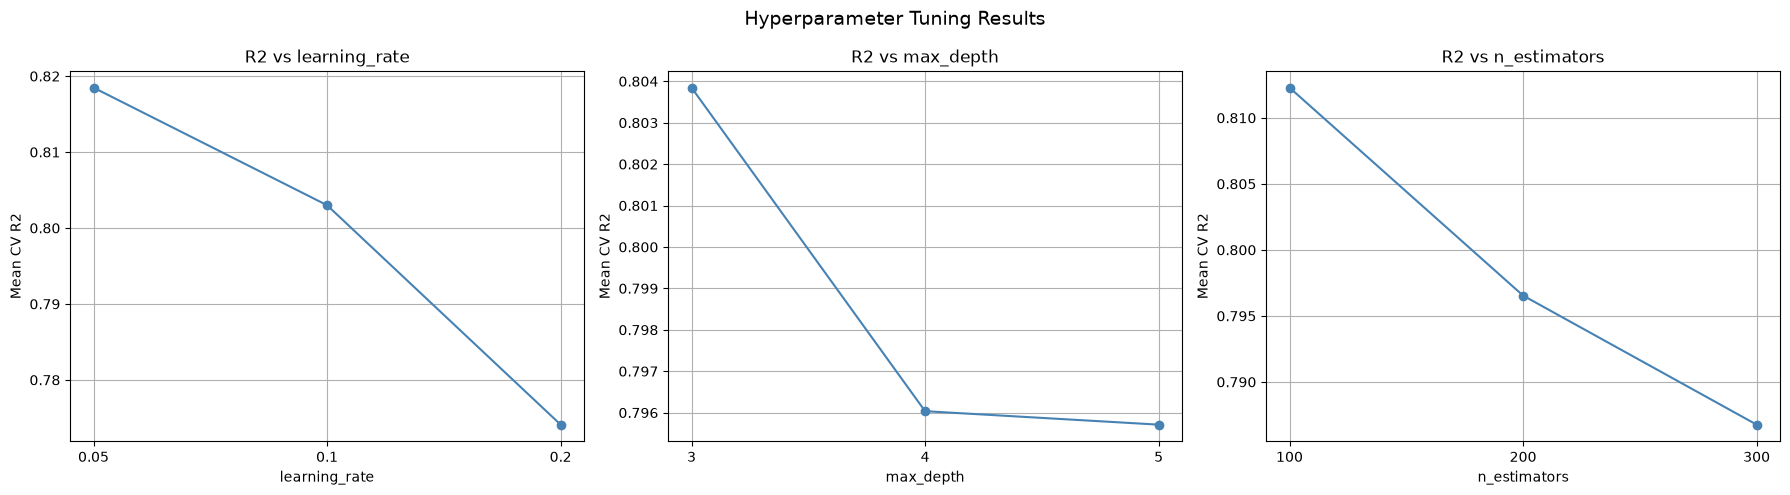

In [18]:
results = pd.DataFrame(grid_search.cv_results_)

# Plot learning rate vs mean R2 score
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, param in zip(axes, ['param_learning_rate', 'param_max_depth', 'param_n_estimators']):
    grouped = results.groupby(param)['mean_test_score'].mean()
    ax.plot(grouped.index.astype(str), grouped.values, marker='o', color='steelblue')
    ax.set_title(f'R2 vs {param.replace("param_", "")}')
    ax.set_xlabel(param.replace("param_", ""))
    ax.set_ylabel('Mean CV R2')
    ax.grid(True)

plt.suptitle('Hyperparameter Tuning Results', fontsize=14)
plt.tight_layout()
plt.show()

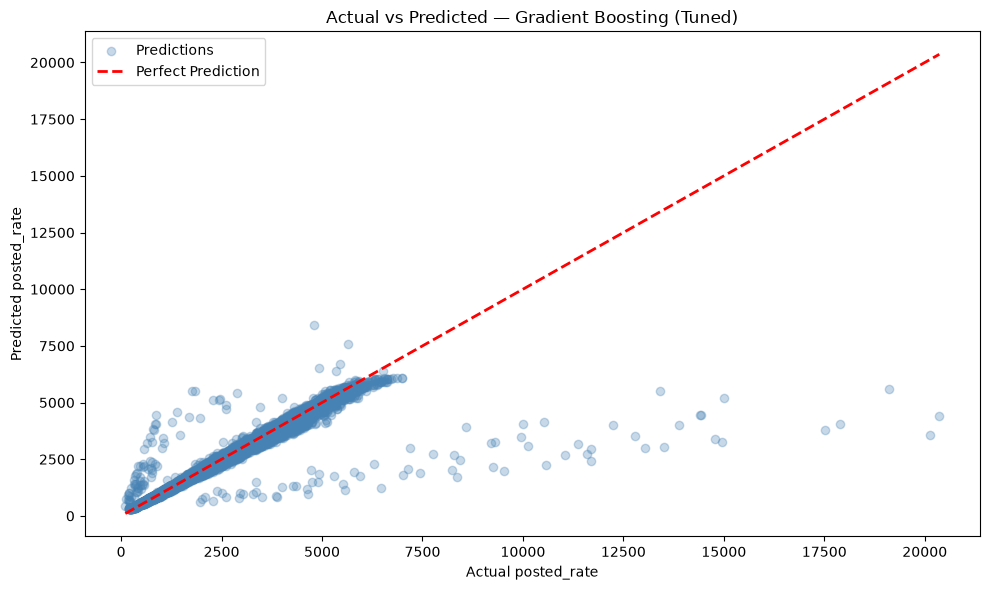

In [19]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, preds, alpha=0.3, color='steelblue', label='Predictions')
plt.plot([y_test.min(), y_test.max()], 
         [y_test.min(), y_test.max()], 
         'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual posted_rate')
plt.ylabel('Predicted posted_rate')
plt.title('Actual vs Predicted — Gradient Boosting (Tuned)')
plt.legend()
plt.tight_layout()
plt.show()

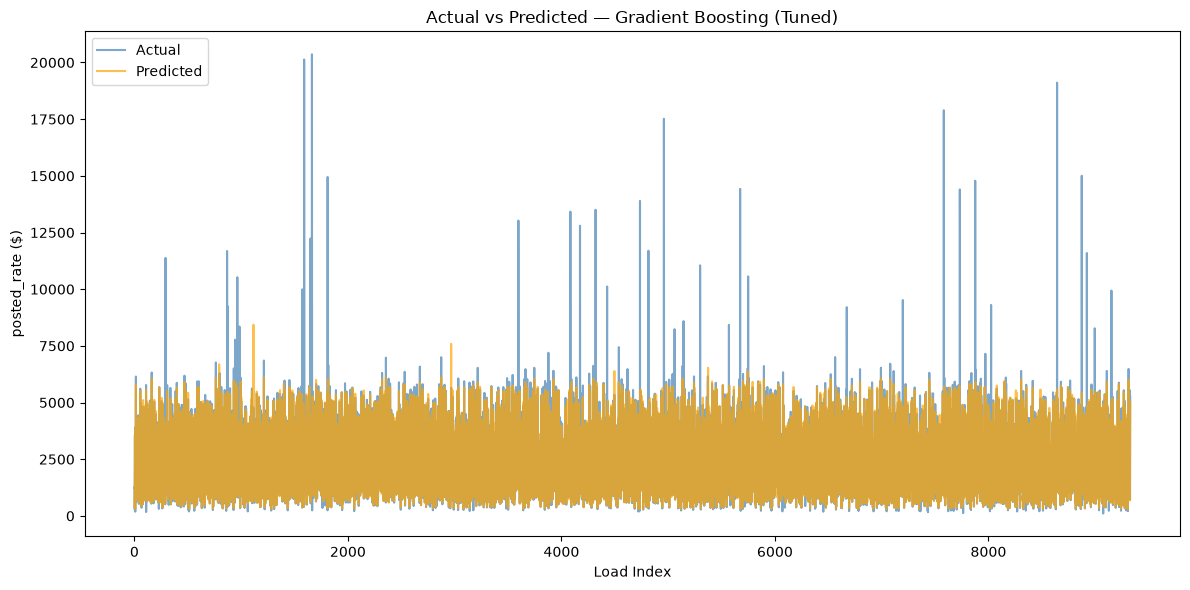

In [20]:
plt.figure(figsize=(12, 6))
plt.plot(range(len(y_test)), y_test.values,  color='steelblue', label='Actual',    alpha=0.7)
plt.plot(range(len(y_test)), preds,           color='orange',    label='Predicted', alpha=0.7)
plt.xlabel('Load Index')
plt.ylabel('posted_rate ($)')
plt.title('Actual vs Predicted — Gradient Boosting (Tuned)')
plt.legend()
plt.tight_layout()
plt.show()

                       Model         MAE        RMSE        R2
0          Gradient Boosting  160.587001  653.285765  0.817044
5  Gradient Boosting (Tuned)  158.763156  656.637285  0.815162
1                      Lasso  198.965457  665.858145  0.809934
2          Linear Regression  199.752205  666.067199  0.809815
3                      Ridge  199.745963  666.067519  0.809815
4              Random Forest  178.500561  670.203635  0.807445


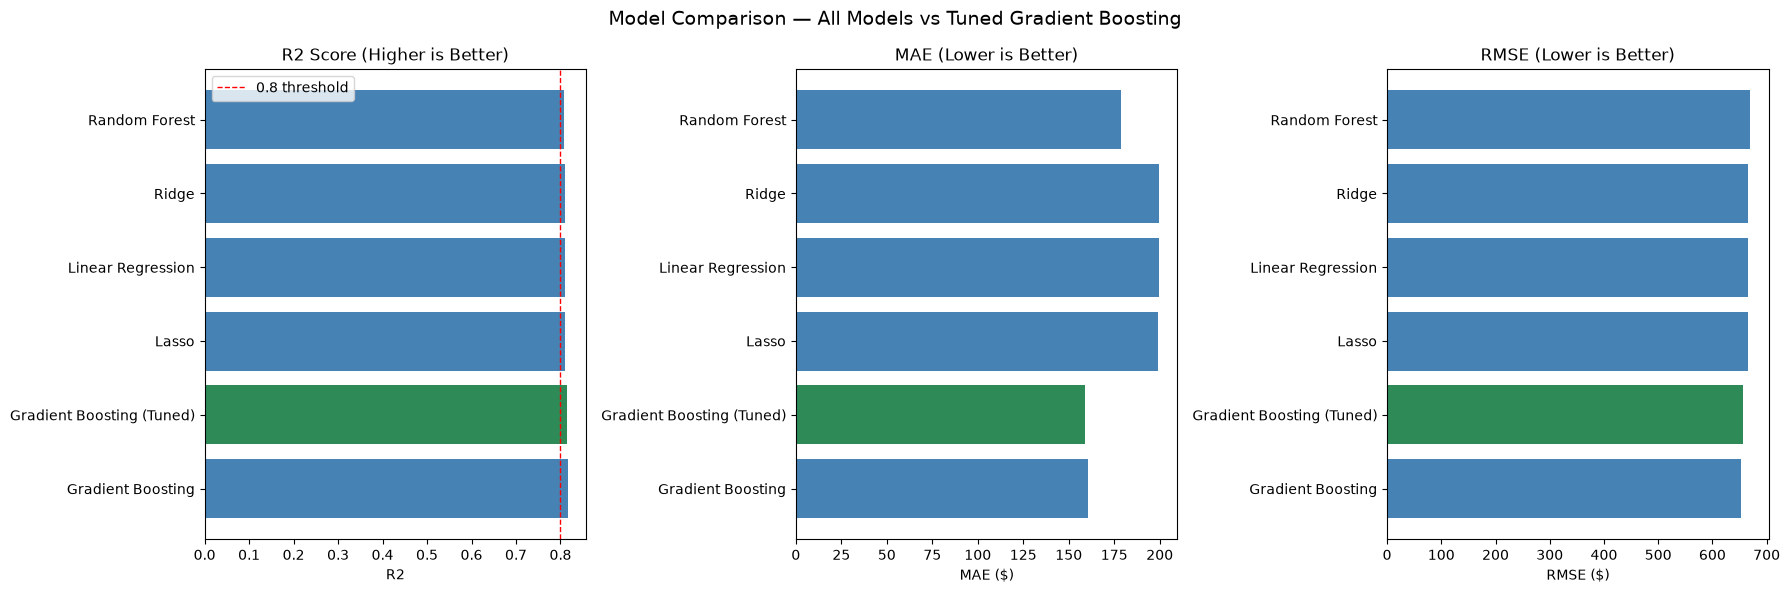

In [22]:
# Add tuned GB to results
tuned_results = {
    'Model': 'Gradient Boosting (Tuned)',
    'MAE'  : mae,
    'RMSE' : rmse,
    'R2'   : r2
}

comparison_df = pd.concat([
    results_df, 
    pd.DataFrame([tuned_results])
], ignore_index=True).sort_values('R2', ascending=False)

print(comparison_df)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

colors = ['steelblue' if m != 'Gradient Boosting (Tuned)' else 'seagreen' 
          for m in comparison_df['Model']]

# R2
axes[0].barh(comparison_df['Model'], comparison_df['R2'], color=colors)
axes[0].set_title('R2 Score (Higher is Better)')
axes[0].set_xlabel('R2')
axes[0].axvline(0.8, color='red', linestyle='--', linewidth=1, label='0.8 threshold')
axes[0].legend()

# MAE
axes[1].barh(comparison_df['Model'], comparison_df['MAE'], color=colors)
axes[1].set_title('MAE (Lower is Better)')
axes[1].set_xlabel('MAE ($)')

# RMSE
axes[2].barh(comparison_df['Model'], comparison_df['RMSE'], color=colors)
axes[2].set_title('RMSE (Lower is Better)')
axes[2].set_xlabel('RMSE ($)')

plt.suptitle('Model Comparison — All Models vs Tuned Gradient Boosting', fontsize=14)
plt.tight_layout()
plt.show()

In [23]:
joblib.dump(best_gb, '../weights/best_model_gb_tuned.pkl')
print("Saved best_model_gb_tuned.pkl")
print("Best params:", grid_search.best_params_)

Saved best_model_gb_tuned.pkl
Best params: {'learning_rate': 0.05, 'max_depth': 4, 'min_samples_split': 2, 'n_estimators': 100}
